# 🔍 실습 — 유사도와 한국어 전처리 (학생용)

코사인 유사도, Pecab 한국어 전처리, 희소 행렬을 실습합니다.

> **🖥️ 환경 설정**
> - 로컬 `UD_26` 실행: `uv run jupyter lab`
> - 로컬 `UD_26` 패키지 에러: `uv add pecab scikit-learn pandas seaborn matplotlib koreanize-matplotlib`
> - Colab 패키지 에러: `!pip install pecab scikit-learn pandas seaborn matplotlib koreanize-matplotlib -q`

> **⌨️ 단축키 안내**
> | 단축키 | 동작 |
> |--------|------|
> | `Shift + Enter` | 셀 실행 후 다음 셀 이동 |
> | `Esc → A` | 위에 셀 삽입 |
> | `Esc → B` | 아래에 셀 삽입 |
> | `Esc → DD` | 셀 삭제 |

In [ ]:
# 패키지 설치가 필요할 때만 참고하세요.
# - 로컬 UD_26: uv add pecab scikit-learn pandas seaborn matplotlib koreanize-matplotlib
# - Colab: !pip install pecab scikit-learn pandas seaborn matplotlib koreanize-matplotlib -q

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from pecab import PeCab
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

pecab = PeCab()

## 📌 §310 코사인 유사도

TF-IDF 행렬로부터 코사인 유사도를 계산하고 시각화합니다.

[→ §310 강의노트](../notes/UD-05-310__cosine-similarity.md)

🔗 [scikit-learn cosine_similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html)

In [3]:
# 📌 §310 cosine_similarity 계산
corpus = [
    "코로나 거리두기와 코로나 상생지원금 문의입니다.",
    "지하철 운행시간과 지하철 요금 문의입니다.",
    "지하철 승강장 문의입니다.",
    "택시 승강장 문의입니다."
]

# 코드를 작성해주세요 👇
tfidfvect = TfidfVectorizer()
dtm = tfidfvect.fit_transform(corpus)

# 코사인 유사도 행렬 계산
cos_matrix = cosine_similarity(dtm)
print(cos_matrix.round(3))

# 예상 출력:
# [[1.    0.05  0.088 0.079]
#  [0.05  1.    0.462 0.091]
#  [0.088 0.462 1.    0.584]
#  [0.079 0.091 0.584 1.   ]]

[[1.    0.05  0.088 0.079]
 [0.05  1.    0.564 0.091]
 [0.088 0.564 1.    0.528]
 [0.079 0.091 0.528 1.   ]]


Text(0.5, 1.0, '문서 간 코사인 유사도')

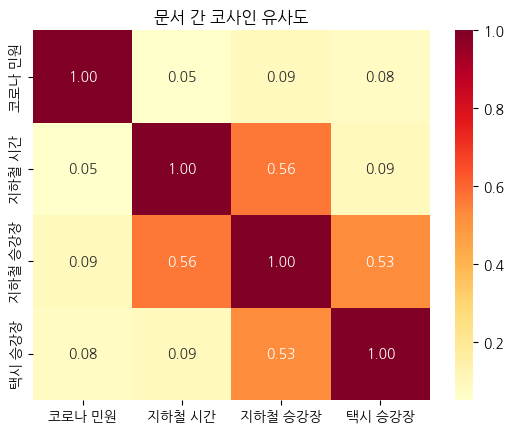

In [4]:
# 📌 §310 히트맵 시각화
# 코드를 작성해주세요 👇
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 히트맵 시각화
labels = ["코로나 민원", "지하철 시간", "지하철 승강장", "택시 승강장"]
df_cos = pd.DataFrame(cos_matrix, index=labels, columns=labels)

sns.heatmap(df_cos, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("문서 간 코사인 유사도")

# 예상 출력: 대각선이 1.0이고, 승강장 관련 문서끼리 색이 진한 히트맵

## 📌 §320 한국어 TF-IDF 전처리 (Pecab)

공백 분리의 한계를 확인하고, Pecab으로 명사를 추출하여 TF-IDF에 적용합니다.

[→ §320 강의노트](../notes/UD-05-320__korean-tfidf-pecab.md)

In [5]:
# 📌 §320 공백 분리 문제
text = "코로나거리두기와 상생지원금을 문의합니다"

# 코드를 작성해주세요 👇
tokens = text.split()
print(tokens)

# 예상 출력: ['코로나거리두기와', '상생지원금을', '문의합니다']

['코로나거리두기와', '상생지원금을', '문의합니다']


In [6]:
# 📌 §320 Pecab.nouns() + join
corpus_raw = [
    "코로나 거리두기와 코로나 상생지원금 문의입니다.",
    "지하철 운행시간과 지하철 요금 문의입니다.",
    "지하철 승강장 문의입니다.",
    "택시 승강장 문의입니다."
]

# 코드를 작성해주세요 👇
from pecab import PeCab

pecab = PeCab()

# Step 1: 각 문서에서 명사 추출 → 공백으로 합치기
corpus_raw = [
	"코로나 거리두기와 코로나 상생지원금 문의입니다.",
	"지하철 운행시간과 지하철 요금 문의입니다.",
	"지하철 승강장 문의입니다.",
	"택시 승강장 문의입니다."
]

corpus_pecab = []
for text in corpus_raw:
	nouns = pecab.nouns(text)         # 명사만 추출
	joined = ' '.join(nouns)          # 공백으로 합치기
	corpus_pecab.append(joined)

print(corpus_pecab)

# 예상 출력: ['코로나 거리두기 코로나 상생지원금 문의', '지하철 운행시간 지하철 요금 문의', ...]

['코 코로나 상생 지원금 문 입 니', '지하철 운행 시간 지하철 요금 문의', '지하철 승강장 문의', '택시 승강장 문의']


c:\Users\kik32\workspace\unstructured-data-processing\.venv\Lib\site-packages\pecab\_tokenizer.py:265: RuntimeWarning: overflow encountered in scalar add
  from_pos_data.costs[idx]


In [7]:
# 📌 §320 TfidfVectorizer에 전달
# 코드를 작성해주세요 👇
from sklearn.feature_extraction.text import TfidfVectorizer

# Pecab 전처리된 corpus → 기본 TfidfVectorizer에 전달
tfidfvect = TfidfVectorizer()
dtm = tfidfvect.fit_transform(corpus_pecab)

vocab = tfidfvect.get_feature_names_out()
print(f"단어 수: {len(vocab)}")
print(vocab)

# 예상 출력: 단어 수: 8 (또는 유사 — 조사가 제거됨)

단어 수: 10
['문의' '상생' '승강장' '시간' '요금' '운행' '지원금' '지하철' '코로나' '택시']


## 📌 §320 희소 행렬

TF-IDF 행렬의 희소성을 확인하고, sparse 형식의 특징을 이해합니다.

[→ §320 강의노트](../notes/UD-05-320__korean-tfidf-pecab.md)

In [8]:
# 📌 §320 0이 아닌 값 비율
# 코드를 작성해주세요 👇
nonzero_ratio = dtm.nnz / (dtm.shape[0] * dtm.shape[1])
print(f"행렬 크기: {dtm.shape}")
print(f"0이 아닌 값 비율: {nonzero_ratio:.1%}")

# 예상 출력: 0이 아닌 값 비율: ~39%

행렬 크기: (4, 10)
0이 아닌 값 비율: 35.0%


In [9]:
# 📌 §320 type 확인 + print
# 코드를 작성해주세요 👇
print(type(dtm))

print(dtm)

# 예상 출력: <class 'scipy.sparse._csr.csr_matrix'>
# 예상 출력:
#   (0, 2)	0.399...
#   (0, 5)	0.799...
#   ...

<class 'scipy.sparse._csr.csr_matrix'>
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14 stored elements and shape (4, 10)>
  Coords	Values
  (0, 8)	0.5773502691896257
  (0, 1)	0.5773502691896257
  (0, 6)	0.5773502691896257
  (1, 7)	0.6495101462986943
  (1, 5)	0.4119106315220916
  (1, 3)	0.4119106315220916
  (1, 4)	0.4119106315220916
  (1, 0)	0.2629172203798441
  (2, 7)	0.6136667440107333
  (2, 0)	0.4968161174826459
  (2, 2)	0.6136667440107333
  (3, 0)	0.4480997313625986
  (3, 2)	0.5534923152870045
  (3, 9)	0.7020348194149619


In [13]:
# 📌 §320 .toarray() → DataFrame
# 코드를 작성해주세요 👇
import pandas as pd

# 소규모 데이터: 문제 없음
df = pd.DataFrame(dtm.toarray(), columns=vocab)

print(df)

# 예상 출력: Pecab 전처리된 단어들의 TF-IDF 값 DataFrame

         문의       상생       승강장        시간        요금        운행      지원금  \
0  0.000000  0.57735  0.000000  0.000000  0.000000  0.000000  0.57735   
1  0.262917  0.00000  0.000000  0.411911  0.411911  0.411911  0.00000   
2  0.496816  0.00000  0.613667  0.000000  0.000000  0.000000  0.00000   
3  0.448100  0.00000  0.553492  0.000000  0.000000  0.000000  0.00000   

        지하철      코로나        택시  
0  0.000000  0.57735  0.000000  
1  0.649510  0.00000  0.000000  
2  0.613667  0.00000  0.000000  
3  0.000000  0.00000  0.702035  


In [14]:
# 📌 §320 sparse 직접 유사도
# 코드를 작성해주세요 👇
# 실전 패턴: .toarray() 없이 유사도 계산
from sklearn.metrics.pairwise import cosine_similarity

# dtm은 sparse matrix 그대로 전달 가능
cos_matrix = cosine_similarity(dtm)  # ← .toarray() 불필요!
print(cos_matrix)

# 예상 출력: .toarray() 없이도 동일한 유사도 행렬 출력

[[1.         0.         0.         0.        ]
 [0.         1.         0.52920429 0.11781314]
 [0.         0.52920429 1.         0.562283  ]
 [0.         0.11781314 0.562283   1.        ]]
